In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm
from matplotlib import patches
import mplhep as hep
import os
from tqdm import tqdm
import ipywidgets as widget
import xsec
import itertools

Welcome to JupyROOT 6.30/04


C++ methods for defining the event weights in MC. The kernel needs to be restarted to test a new weight definition.

In [2]:
ROOT.gInterpreter.Declare("""
float compute_weight( float norm, float triggerXSF, float triggerSF, float pileupWeight, float pileupJetIDWeight, float lepIdSF, float EGammaGsfSF, float isoSF, float L1NonPrefiringProb_CommonCalc, float MCWeight_MultiLepCalc, float btagDeepJetWeight, float btagDeepJet2DWeight_HTnj ){
    return norm * triggerSF * pileupWeight * pileupJetIDWeight * lepIdSF * EGammaGsfSF * isoSF * L1NonPrefiringProb_CommonCalc * ( MCWeight_MultiLepCalc / abs( MCWeight_MultiLepCalc ) ) * btagDeepJetWeight * btagDeepJet2DWeight_HTnj;
}
""")

True

In [3]:
ROOT.gInterpreter.Declare("""
float compute_weight_ttbar( float norm, float triggerXSF, float triggerSF, float pileupWeight, float pileupJetIDWeight, float topPtWeight13TeV, float lepIdSF, float EGammaGsfSF, float isoSF, float L1NonPrefiringProb_CommonCalc, float MCWeight_MultiLepCalc, float btagDeepJetWeight, float btagDeepJet2DWeight_HTnj ){
    return norm * triggerSF * pileupWeight * pileupJetIDWeight * topPtWeight13TeV * lepIdSF * EGammaGsfSF * isoSF * L1NonPrefiringProb_CommonCalc * ( MCWeight_MultiLepCalc / abs( MCWeight_MultiLepCalc ) ) * btagDeepJetWeight * btagDeepJet2DWeight_HTnj;
}
""")

True

In [4]:
era = "2017"
postfix = "step2" # postfix for save directory
rPath = "root://brux30.hep.brown.edu:1094//store/user/dali/"
#rPath = "root://cmseos.fnal.gov//store/user/dsunyou/"
rDir = rPath + "FWLJMET106XUL_singleLep{}UL_RunIISummer20_3t_step2/nominal/".format( era )
nTree = "ljmet"
fDATA = [
    "SingleElectron_hadd.root",
    #"EGamma_hadd.root",
    "SingleMuon_hadd.root"
]
fSIG = [
    "TTTJ_TuneCP5_13TeV-madgraph-pythia8_hadd.root",
    "TTTW_TuneCP5_13TeV-madgraph-pythia8_hadd.root"
]
fBKG = {
    "TTTT": [
        "TTTT_TuneCP5_13TeV-amcatnlo-pythia8_hadd.root",
        #"TTTT_TuneCP5_13TeV-amcatnlo-pythia8_1_hadd.root",
        #"TTTT_TuneCP5_13TeV-amcatnlo-pythia8_2_hadd.root",
        #"TTTT_TuneCP5_13TeV-amcatnlo-pythia8_3_hadd.root",
    ],
    "TTH": [
        "ttHTobb_M125_TuneCP5_13TeV-powheg-pythia8_hadd.root",
        "ttHToNonbb_M125_TuneCP5_13TeV-powheg-pythia8_hadd.root",
    ],
    "TOP": [
        "TTHH_TuneCP5_13TeV-madgraph-pythia8_hadd.root",
        "TTWH_TuneCP5_13TeV-madgraph-pythia8_hadd.root",
        "TTWW_TuneCP5_13TeV-madgraph-pythia8_hadd.root",
        "TTWZ_TuneCP5_13TeV-madgraph-pythia8_hadd.root",
        "TTZH_TuneCP5_13TeV-madgraph-pythia8_hadd.root",
        "TTZZ_TuneCP5_13TeV-madgraph-pythia8_hadd.root",
        "TTZToLLNuNu_M-10_TuneCP5_13TeV-amcatnlo-pythia8_hadd.root",
        "TTWJetsToQQ_TuneCP5_13TeV-amcatnloFXFX-madspin-pythia8_hadd.root", 
        "TTWJetsToLNu_TuneCP5_13TeV-amcatnloFXFX-madspin-pythia8_hadd.root",
        "TTZToLL_M-1to10_TuneCP5_13TeV-amcatnlo-pythia8_hadd.root",
    ],
    "ST": [
        "ST_s-channel_4f_leptonDecays_TuneCP5_13TeV-amcatnlo-pythia8_hadd.root",
        "ST_t-channel_top_4f_InclusiveDecays_TuneCP5_13TeV-powheg-madspin-pythia8_hadd.root",
        "ST_t-channel_antitop_4f_InclusiveDecays_TuneCP5_13TeV-powheg-madspin-pythia8_hadd.root",
        "ST_tW_top_5f_inclusiveDecays_TuneCP5_13TeV-powheg-pythia8_hadd.root",
        "ST_tW_antitop_5f_inclusiveDecays_TuneCP5_13TeV-powheg-pythia8_hadd.root",
    ],
    "EWK": [
        "WW_TuneCP5_13TeV-pythia8_hadd.root",
        "WZ_TuneCP5_13TeV-pythia8_hadd.root",
        "ZZ_TuneCP5_13TeV-pythia8_hadd.root",
        "DYJetsToLL_M-50_HT-200to400_TuneCP5_PSweights_13TeV-madgraphMLM-pythia8_hadd.root",
        "DYJetsToLL_M-50_HT-400to600_TuneCP5_PSweights_13TeV-madgraphMLM-pythia8_hadd.root",
        "DYJetsToLL_M-50_HT-600to800_TuneCP5_PSweights_13TeV-madgraphMLM-pythia8_hadd.root",
        "DYJetsToLL_M-50_HT-800to1200_TuneCP5_PSweights_13TeV-madgraphMLM-pythia8_hadd.root",
        "DYJetsToLL_M-50_HT-1200to2500_TuneCP5_PSweights_13TeV-madgraphMLM-pythia8_hadd.root",
        "DYJetsToLL_M-50_HT-2500toInf_TuneCP5_PSweights_13TeV-madgraphMLM-pythia8_hadd.root",
        "WJetsToLNu_HT-200To400_TuneCP5_13TeV-madgraphMLM-pythia8_hadd.root",
        "WJetsToLNu_HT-400To600_TuneCP5_13TeV-madgraphMLM-pythia8_hadd.root",
        "WJetsToLNu_HT-600To800_TuneCP5_13TeV-madgraphMLM-pythia8_hadd.root",
        "WJetsToLNu_HT-800To1200_TuneCP5_13TeV-madgraphMLM-pythia8_hadd.root",
        "WJetsToLNu_HT-1200To2500_TuneCP5_13TeV-madgraphMLM-pythia8_hadd.root",
        "WJetsToLNu_HT-2500ToInf_TuneCP5_13TeV-madgraphMLM-pythia8_hadd.root",
    ],
    "QCD": [
        #"QCD_HT200to300_TuneCP5_PSWeights_13TeV-madgraph-pythia8_hadd.root",
        "QCD_HT300to500_TuneCP5_PSWeights_13TeV-madgraph-pythia8_hadd.root",
        "QCD_HT500to700_TuneCP5_PSWeights_13TeV-madgraph-pythia8_hadd.root",
        "QCD_HT700to1000_TuneCP5_PSWeights_13TeV-madgraph-pythia8_hadd.root",
        "QCD_HT1000to1500_TuneCP5_PSWeights_13TeV-madgraph-pythia8_hadd.root",
        "QCD_HT1500to2000_TuneCP5_PSWeights_13TeV-madgraph-pythia8_hadd.root",
        "QCD_HT2000toInf_TuneCP5_PSWeights_13TeV-madgraph-pythia8_hadd.root",
    ],   
    "TTBAR": [
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_tt1b_hadd.root",
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_tt2b_hadd.root",
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_ttbb_hadd.root",
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_ttcc_hadd.root",
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_ttjj_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_tt1b_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_tt2b_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_ttbb_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_ttcc_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_ttjj_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_tt1b_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_tt2b_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_ttbb_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_ttcc_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_ttjj_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_tt1b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_tt2b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttbb_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttcc_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_1_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_2_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_3_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_4_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_5_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_6_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_7_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_8_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_9_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_10_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_tt1b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_tt2b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttbb_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttcc_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttjj_hadd.root",
    ]
}

In [5]:
fBase = "DataPastTriggerX == 1 && MCPastTriggerX == 1 && AK4HT > 450 && NJetsCSV_JetSubCalc >= 1 && minDR_lepJet > 0.4"
if era == "2018":
    fBase += " && ( ( isElectron == 1 && ( leptonEta_MultiLepCalc > -1.3 ||  ( leptonPhi_MultiLepCalc < -1.57 || leptonPhi_MultiLepCalc > -0.87 ) ) ) || isMuon == 1 )"
#trigger = "1" if ( era == "2016APV" or era == "2016" ) else "triggerSF"
trigger = "triggerSF"
deepJet1D = "btagDeepJetWeight"
deepJet2D = "btagDeepJet2DWeight_HTnj"
pileupJetID = "pileupJetIDWeight"
variables = [
    "NJets_JetSubCalc",
    "NJetsCSV_JetSubCalc",
    "NresolvedTops1pFake",
    "NJetsPU_JetSubCalc",
    #"nPV_MultiLepCalc",
    "isElectron",
    "isMuon",
    #"theJetPt_JetSubCalc_PtOrdered",
    #"theJetEta_JetSubCalc_PtOrdered",
    #"theJetPhi_JetSubCalc_PtOrdered",
    "AK4HT",
    #"leptonPt_MultiLepCalc",
    #"leptonEta_MultiLepCalc",
    #"leptonPhi_MultiLepCalc",
    "corr_met_MultiLepCalc",
    #"corr_met_phi_MultiLepCalc",
    "minDR_lepJet",
    #"DNN_1to40_nJ4pnB1p",
    #"HOTGoodTrijet2_dRtridijet",
    #"deltaR_lepbJetInMinMlb",
    #"HT_bjets",
    #"HOTGoodTrijet1_pTratio",
    #"secondJetPt",
    #"BDTtrijet2",
    #"NJets_JetSubCalc",
    #"HOTGoodTrijet2_dijetmass",
    #"HT_2m",
    #"ratio_HTdHT4leadjets",
    #"fourthcsvb_bb",
    #"HOTGoodTrijet2_csvJetnotdijet",
    #"thirdcsvb_bb",
    #"aveCSVpt",
    #"MT_lepMet",
    #"hemiout",
    #"mass_lepBJet_mindr",
    #"FW_momentum_6",
    #"NJetsCSV_JetSubCalc",
    #"HOTGoodTrijet1_dijetmass",
    #"aveBBdr",
    #"mass_maxJJJpt",
    #"BDTtrijet4",
    #"Sphericity",
    #"firstcsvb_bb",
    #"csvJet4",
    #"HOTGoodTrijet1_dRtrijetJetnotdijet",
    #"centrality",
    #"BDTtrijet3",
    #"mass_lepJets2",
    #"Aplanarity",
    #"mass_lepJets1",
    #"leptonPt_MultiLepCalc",
    #"FW_momentum_4",
    #"deltaR_lepBJet_maxpt",
    #"corr_met_MultiLepCalc",
    #"deltaEta_maxBB",
    #"mass_lepBJet0",
    #"FW_momentum_5",
    #"deltaPhi_lepJetInMinMljet",
    #"M_allJet_W"
]
rDF = { "DATA": {}, "SIG": {}, "BKG": {} }
print( "Applying the selection: {}".format( fBase ) )
print( "Loading data:" )
for f in tqdm( fDATA ):
    rDF["DATA"][f] = ROOT.RDataFrame( nTree, rDir + f ).Filter( fBase ).AsNumpy( columns = variables )
print( "Loading signal:" )
for f in tqdm( fSIG ):
    rDF_ = ROOT.RDataFrame( nTree, rDir + f ).Filter( fBase ).Define( "weight", "compute_weight( {}, triggerXSF, {}, pileupWeight, pileupJetIDWeight, lepIdSF, EGammaGsfSF, isoSF, L1NonPrefiringProb_CommonCalc, MCWeight_MultiLepCalc, {}, {} )".format( xsec.norm[f], trigger, deepJet1D, deepJet2D ) )
    rDF["SIG"][f] = rDF_.AsNumpy( columns = variables + [ "weight" ] )
for g in fBKG:
    rDF["BKG"][g] = {}
    print( "Loading background group: " + g )
    for f in tqdm( fBKG[g] ):
        if g == "TTBAR":
            if "TTToSemiLepton" in f and "HT500" in f:
                rDF_ = ROOT.RDataFrame( nTree, rDir + f ).Filter( fBase + " && isHTgt500Njetge9 == 1" ).Define( "weight", "compute_weight_ttbar( {}, triggerXSF, {}, pileupWeight, {}, topPtWeight13TeV, lepIdSF, EGammaGsfSF, isoSF, L1NonPrefiringProb_CommonCalc, MCWeight_MultiLepCalc, {}, {} )".format( xsec.norm[f], trigger, pileupJetID, deepJet1D, deepJet2D ) )
            elif "TTToSemiLepton" in f and "HT500" not in f:
                rDF_ = ROOT.RDataFrame( nTree, rDir + f ).Filter( fBase + " && isHTgt500Njetge9 == 0" ).Define( "weight", "compute_weight_ttbar( {}, triggerXSF, {}, pileupWeight, {}, topPtWeight13TeV, lepIdSF, EGammaGsfSF, isoSF, L1NonPrefiringProb_CommonCalc, MCWeight_MultiLepCalc, {}, {} )".format( xsec.norm[f], trigger, pileupJetID, deepJet1D, deepJet2D ) )
            else:
                rDF_ = ROOT.RDataFrame( nTree, rDir + f ).Filter( fBase ).Define( "weight", "compute_weight_ttbar( {}, triggerXSF, {}, pileupWeight, {}, topPtWeight13TeV, lepIdSF, EGammaGsfSF, isoSF, L1NonPrefiringProb_CommonCalc, MCWeight_MultiLepCalc, {}, {} )".format( xsec.norm[f], trigger, pileupJetID, deepJet1D, deepJet2D ) )
            rDF["BKG"][g][f] = rDF_.AsNumpy( columns = variables + [ "weight" ] )
        else:
            rDF_ = ROOT.RDataFrame( nTree, rDir + f ).Filter( fBase ).Define( "weight", "compute_weight( {}, triggerXSF, {}, pileupWeight, {}, lepIdSF, EGammaGsfSF, isoSF, L1NonPrefiringProb_CommonCalc, MCWeight_MultiLepCalc, {}, {} )".format( xsec.norm[f], trigger, pileupJetID, deepJet1D, deepJet2D ) )
            rDF["BKG"][g][f] = rDF_.AsNumpy( columns = variables + [ "weight" ] )

Applying the selection: DataPastTriggerX == 1 && MCPastTriggerX == 1 && AK4HT > 450 && NJetsCSV_JetSubCalc >= 1 && minDR_lepJet > 0.4
Loading data:


100%|██████████| 2/2 [00:12<00:00,  6.05s/it]


Loading signal:


100%|██████████| 2/2 [00:04<00:00,  2.18s/it]


Loading background group: TTTT


...

100%|██████████| 15/15 [00:38<00:00,  2.57s/it]


Loading background group: QCD


100%|██████████| 6/6 [00:07<00:00,  1.33s/it]


Loading background group: TTBAR


100%|██████████| 34/34 [05:50<00:00, 10.31s/it]


### Apply any selection

In [6]:
ops = {
    ">=": lambda x, y: x >= y,
    ">":  lambda x, y: x > y,
    "<":  lambda x, y: x < y,
    "<=": lambda x, y: x <= y,
    "==": lambda x, y: x == y
}

In [7]:
channel = widget.Dropdown( options = [ "isElectron", "isMuon", "isLepton" ], value = "isLepton" )
channel

Dropdown(index=2, options=('isElectron', 'isMuon', 'isLepton'), value='isLepton')

In [8]:
selection = [
    ( "NJets_JetSubCalc", ">=", 4, "$N_j\geq4$" ),
    #( "NJets_JetSubCalc", "<=", 5, "$N_j\leq5$" ),
    ( "NJetsCSV_JetSubCalc", ">=", 1, "$N_b\geq1$" ),
    #( "NJetsCSV_JetSubCalc", "<", 4, "$N_b<4$" ),
    #( "NresolvedTops1pFake", "==", 0, "$N_{HOT}=0$"),
    #( "NresolvedTops1pFake", ">=", 0, "$N_{HOT}\geq0$"),
    ( "AK4HT", ">", 500, "$H_{T}>500$ GeV" ),
    #( "AK4HT", "<=", 600, "$H_{T}\leq600$" ),
    #( "DNN_1to40_Run2_3v4T_nJ6pnB2p", "<", 0.5, "$DNN_{3v4T}<0.5$" ),
    #( "DNN_1to40_Run2_3v4T_nJ6pnB2p", ">=", 0.5, "$DNN_{3v4T}\geq0.5$" ),
    ( "minDR_lepJet", ">", 0.4, "$Min\ \Delta R(\ell,jet)>0.4$" ),
    ( "corr_met_MultiLepCalc", ">", 20, "$E^{miss}_T>20$ GeV" ),
]

tag = "" 

if channel.value == "isElectron":
    selection.append( ( channel.value, "==", 1, "$e+jets$" ) )
elif channel.value == "isMuon":
    selection.append( ( channel.value, "==", 1, "$\mu+jets$" ) )

In [9]:
mask = { "DATA": {}, "SIG": {}, "BKG": {} }

print( "[INFO] Applying selection on data" )
for f in tqdm( rDF["DATA"] ):
    for selection_ in selection:
        try:
            mask["DATA"][f] &= ops[selection_[1]]( rDF["DATA"][f][selection_[0]], selection_[2] )
        except:
            mask["DATA"][f] = ops[selection_[1]]( rDF["DATA"][f][selection_[0]], selection_[2] )
print( "[INFO] Applying selection on signal" )
for f in tqdm( rDF["SIG"] ):
    for selection_ in selection:
        try:
            mask["SIG"][f] &= ops[selection_[1]]( rDF["SIG"][f][selection_[0]], selection_[2] )
        except:
            mask["SIG"][f] = ops[selection_[1]]( rDF["SIG"][f][selection_[0]], selection_[2] )
print( "[INFO] Applying selection on background" )
for g in tqdm( rDF["BKG"] ):
    mask["BKG"][g] = {}
    for f in rDF["BKG"][g]:
        for selection_ in selection:
            try:
                mask["BKG"][g][f] &= ops[selection_[1]]( rDF["BKG"][g][f][selection_[0]], selection_[2] )
            except:
                mask["BKG"][g][f] = ops[selection_[1]]( rDF["BKG"][g][f][selection_[0]], selection_[2] )

[INFO] Applying selection on data


100%|██████████| 2/2 [00:00<00:00, 636.32it/s]


[INFO] Applying selection on signal


100%|██████████| 2/2 [00:00<00:00, 1589.96it/s]


[INFO] Applying selection on background


100%|██████████| 7/7 [00:00<00:00, 41.24it/s]


### Calculate Statistical Uncertainty and Apply normalization weights

In [10]:
variable_plot = widget.Dropdown( options = sorted( variables ) )
variable_plot

Dropdown(options=('AK4HT', 'NJetsCSV_JetSubCalc', 'NJetsPU_JetSubCalc', 'NJets_JetSubCalc', 'NresolvedTops1pFa…

In [11]:
variable_labels = {
    "NJets_JetSubCalc": ( "$AK4\ Jet\ Multiplicity$", np.linspace( 1, 13, 13 ) ),
    "NJetsCSV_JetSubCalc": ( "$deepJet\ (M)\ Multiplicity$", np.linspace( 0, 7, 8 ) ),
    "nPV_MultiLepCalc": ( "Interaction Multiplicity", np.linspace( 0, 100, 101 ) ),
    "isMuon": ( "isMuon", np.linspace( -1, 1, 3 ) ),
    "isElectron": ( "isElectron", np.linspace( -1, 1, 3 ) ),
    "NJetsPU_JetSubCalc": ( "$Pileup\ Jet\ (T)\ Multiplicity$", np.linspace( -1, 7, 9 ) ),
    "AK4HT": ( "$AK4\ H_T\ [GeV]$", np.linspace( -100, 3500, 37 ) ),
    "minDR_lepJet": ( "$\min\ \Delta{R}(\ell,j)$", np.linspace( 0, 4, 41 ) ),
    "leptonPt_MultiLepCalc": ( "$Lepton\ p_T\ [GeV]$", np.linspace( -20, 820, 43 ) ),
    "leptonEta_MultiLepCalc": ( "$Lepton\ \eta$", np.linspace( -2.6, 2.6, 53 ) ),
    "theJetPt_JetSubCalc_PtOrdered": ( "$AK4\ Jet\ p_T\ [GeV]$", np.linspace( -24, 1224, 53 ) ), 
    "theJetEta_JetSubCalc_PtOrdered": ( "$AK4\ Jet\ \eta$", np.linspace( -2.5, 2.5, 53 ) ),
    "theJetPhi_JetSubCalc_PtOrdered": ( "$AK4\ Jet\ \phi$", np.linspace( -3.15, 3.15, 53 ) ),
    "corr_met_MultiLepCalc": ( "$Missing\ Transverse\ Momentum\ (E_T^{miss})\ [GeV]$", np.linspace( -20, 820, 43 ) ),
    "corr_met_phi_MultiLepCalc": ( "$Missing\ Transverse\ Momentum\ \phi$", np.linspace( -3.20, 3.20, 53 ) ),
    "NresolvedTops1pFake": ( "$HOT-tagged\ Jet\ Multiplicity$", np.linspace( -1, 4, 6 ) ),
    "leptonPhi_MultiLepCalc": ( "$Lepton\ \phi$", np.linspace( -3.20, 3.20, 53 ) ),
    "DNN_1to40_Run2_nJ4pnB1p": ( "$DNN_{1-40}$", np.linspace( -0.02, 1.02, 53 ) ),
    "DNN_1to40_Run2_3v4T_nJ6pnB2p": ( "$DNN_{3v4T}$", np.linspace( -0.02, 1.02, 27 ) ),
    "DNN_1to40_nJ4pnB1p": ( "$DNN_{1-40}$", np.linspace( -0.04, 1.04, 28 ) ),
    "HOTGoodTrijet1_dijetmass": ( "Leading HOT-tagged $M(dijet)$ [GeV]", np.linspace( -10, 200, 22 ) ),
    "HOTGoodTrijet2_dijetmass": ( "Sub-Leading HOT-tagged $M(dijet)$ [GeV]", np.linspace( -10, 200, 22 ) ),
    "thirdcsvb_bb": ( "Third DeepJet Score", np.linspace( -0.1, 1.1, 13 ) ),
    "ratio_HTdHT4leadjets": ( "$H_T$(all Jets) / $H_T$(Leading 4 Jets)", np.linspace( 0.9, 2.1, 13 ) ),
    "BDTtrijet2": ( "$Second\ HOT-tagger\ Score$", np.linspace( -1.1, 1.1, 23 ) ),
    "HT_bjets": ( "$H_T\ b-tagged\ Jets\ [GeV]$", np.linspace( -100, 2000, 22 ) ),
    "aveCSVpt": ( "Average $p_T$-weighted DeepJet Score", np.linspace( -0.1, 1.1, 13 ) ),
    "fourthcsvb_bb": ( "$Fourth\ deepJet\ Score$", np.linspace( -0.1, 1.1, 13 ) ),
    "theJetLeadPt": ( "$Lead\ AK4\ Jet\ p_T\ [GeV]$", np.linspace( 0, 1500, 51 ) ),
    "secondcsvb_bb": ( "$Second\ deepJet\ Score$", np.linspace( -0.1, 1.1, 13 ) ),
    "HOTGoodTrijet1_dRtrijetJetnotdijet": ( "$First\ HOT-tagged\ \Delta r(t,b)$", np.linspace( -0.1, 3.2, 34 ) ),
    "theJetEtaAverage_JetSubCalc": ( "$Average\ AK4\ Jet\ \eta$", np.linspace( -2.4, 2.4, 51 ) ),
    "BJetLeadPt": ( "$Lead\ b-tagged\ Jet\ p_T\ [GeV]$", np.linspace( 0, 1200, 51 ) ),
    "hemiout": ( "Hemiout", np.linspace( -100, 2000, 22 ) ),
    "HT_2m": ( "$H_T\ Lead\ Two\ b-Jets$", np.linspace( -100, 2000, 22 ) ),
    "mass_maxBBmass": ( "$Largest\ b-Jet\ Pair\ Mass\ [GeV]$", np.linspace( -100, 3100, 33 ) ),
    "MT_lepMet": ( "$W\ M_T(Lepton,E^{miss}_T)\ [GeV]$", np.linspace( -10, 300, 32 ) ),
    "secondJetPt": ( "Sub-Leading AK4 Jet $p_T$ [GeV]", np.linspace( -100, 1600, 18 ) ),
    "BDTtrijet3": ( "$Third\ HOT-tagger\ Score$", np.linspace( -1.1, 1.1, 23 ) ),
    "M_allJet_W": ( "$Transverse\ Mass\ of\ Jets+Lepton+MET\ [GeV]$", np.linspace( -100, 5100, 27 ) ),
    "mass_maxJJJpt": ( "Max $M_T$ of AK4 Jet Triplet [GeV]", np.linspace( -100, 3100, 33 ) ),
    "HOTGoodTrijet1_pTratio": ( "$First\ HOT-tagged\ Jet\ p_T\ to\ Trijet\ p_T\ Ratio$", np.linspace( -0.1, 1, 12 ) ),
    "mass_lepBJet_mindr": ( "$M(\ell,b)$ with  Min  $\Delta R(\ell,b)$ [GeV]", np.linspace( -100, 1100, 13 ) ),
    "HOTGoodTrijet2_csvJetnotdijet": ( "Subleading HOT-tagged Jet b-jet deepJet Score", np.linspace( -0.2, 1.2, 15 ) ),
    "BDTtrijet1": ( "Leading HOT-tagger Score", np.linspace( -1.1, 1.1, 23 ) ),
    "centrality": ( "Centrality", np.linspace( -0.1, 1.1, 13 ) ),
    "deltaR_lepBJet_maxpt": ( "$\Delta R(lepton,Leading\ b-jet)$", np.linspace( -0.25, 5.25, 23 ) ),
    "deltaR_lepbJetInMinMlb": ( "Min $M(\ell,jet)$ $\Delta R(\ell,jet)$", np.linspace( -0.1, 3.1, 33 ) ),
    "FW_momentum_1": ( "First Fox-Wolfram Moment", np.linspace( 0, 1, 51 ) ),
    "MT2bb": ( "$M_T\ Leading\ and\ Sub-leading\ b-jet\ [GeV]$", np.linspace( 0, 500, 51 ) ),
    "HOTGoodTrijet2_dRtrijetJetnotdijet": ( "$Second\ HOT-tagged\ Jet\ \Delta R(t,b)$", np.linspace( 0, 3.2, 51 ) ),
    "mass_lepJets0": ( "$M_T\ Lepton\ and\ Leading\ AK4\ Jet\ [GeV]$", np.linspace( 0, 1500, 51 ) ),
    "HOTGoodTrijet2_dRtridijet": ( "$Second\ HOT-tagged\ Jet\ \Delta R(t,W)$", np.linspace( -0.1, 1.3, 15 ) ),
    "Aplanarity": ( "Aplanarity", np.linspace( -0.05, 0.55, 13 ) ),
    "deltaR_minBB": ( "$Minimum\ \Delta R(b-jet\ pair)$", np.linspace( 0, 7, 51 ) ),
    "aveBBdr": ( "$Average\ \Delta R(b-jet\ pair)$", np.linspace( -0.25, 5.25, 23 ) ),
    "FW_momentum_3": ( "Third Fox-Wolfram Moment", np.linspace( -0.1, 1.1, 13 ) ),
    "csvJet4": ( "deepJet Score for Fourth AK4 Jet", np.linspace( -0.1, 1.1, 13 ) ),
    "FW_momentum_4": ( "Fourth Fox-Wolfram Moment", np.linspace( -0.1, 1.1, 13 ) ),
    "BDTtrijet4": ( "$Fourth\ HOT-tagger\ Score$", np.linspace( -1.1, 1.1, 23 ) ),
    "Sphericity": ( "Sphericity", np.linspace( -0.05, 1.05, 23 ) ),
    "firstcsvb_bb": ( "First deepJet Score", np.linspace( -0.1, 1.1, 13 ) ),
    "mass_lepJets2": ( "$M_T\ Lepton\ and\ Third\ AK4\ Jet\ [GeV]$", np.linspace( -100, 1900, 21 ) ),
    "mass_lepJets1": ( "$M_T\ Lepton\ and\ Second\ AK4\ Jet\ [GeV]$", np.linspace( -100, 1900, 21 ) ),
    "deltaEta_maxBB": ( "Max $M(b,b)$ $\Delta\eta(b,b)$", np.linspace( -5, 5, 31 ) ),
    "mass_lepBJet0": ( "$M(\ell,b_1)$ [GeV]", np.linspace( -100, 1900, 21 ) ),
    "FW_momentum_5": ( "Fifth Fox-Wolfram Moment", np.linspace( -0.1, 1.1, 13 ) ),
    "deltaPhi_lepJetInMinMljet": ( "Min $M(\ell,j)$ $\Delta\phi(\ell,j)$", np.linspace( -3.5, 3.5, 31 ) ),
    "M_allJet_W": ( "M_T(jets,$E_T^{miss},\ell$) [GeV]", np.linspace( 0, 5200, 27 ) )
}

In [12]:
bins = variable_labels[ variable_plot.value ][1]

hist = { "DATA": {}, "SIG": {}, "BKG": {} }
hist_norm = { "DATA": {}, "SIG": {}, "BKG": {} }
hist_err = { "DATA": {}, "SIG": {}, "BKG": {} }

print( "[INFO] Binning data" )
for f in tqdm( rDF["DATA"] ):
    if channel.value == "isElectron" and f == "SingleMuon_hadd.root": continue
    if channel.value == "isMuon" and f in [ "SingleElectron_hadd.root", "EGamma_hadd.root" ]: continue
    try: # single entry per branch
        hist["DATA"][f] = np.histogram( np.clip( rDF["DATA"][f][variable_plot.value][ mask["DATA"][f] ], bins[0], bins[-1] ), bins = bins )
        hist_norm["DATA"][f] = np.histogram( np.clip( rDF["DATA"][f][variable_plot.value][ mask["DATA"][f] ], bins[0], bins[-1] ), bins = bins )
        hist_err["DATA"][f] = np.sqrt( np.sum( hist["DATA"][f][0] ) )
    except: # vector per branch
        hist["DATA"][f] = np.histogram( np.clip( np.concatenate( [ list(v_) for v_ in rDF["DATA"][f][variable_plot.value][ mask["DATA"][f] ] ] ), bins[0], bins[-1] ), bins = bins )
        hist_norm["DATA"][f] = np.histogram( np.clip( np.concatenate( [ list(v_) for v_ in rDF["DATA"][f][variable_plot.value][ mask["DATA"][f] ] ] ), bins[0], bins[-1] ), bins = bins )
        hist_err["DATA"][f] = np.sqrt( np.sum( hist["DATA"][f][0] ) )
print( "[INFO] Binning signal" )
for f in tqdm( rDF["SIG"] ):
    try:
        hist["SIG"][f] = np.histogram( np.clip( rDF["SIG"][f][variable_plot.value][ mask["SIG"][f] ], bins[0], bins[-1] ), bins = bins )
        hist_norm["SIG"][f] = np.histogram( 
            np.clip( rDF["SIG"][f][variable_plot.value][ mask["SIG"][f] ], bins[0], bins[-1] ), 
            weights = rDF["SIG"][f]["weight"][ mask["SIG"][f] ],
            bins = bins )
        hist_err["SIG"][f] = np.sqrt( np.sum( mask["SIG"][f] ) ) * np.sum( hist_norm["SIG"][f][0] ) / np.sum( mask["SIG"][f] )
    except:
        hist["SIG"][f] = np.histogram( np.clip( np.concatenate( [ list(v_) for v_ in rDF["SIG"][f][variable_plot.value][ mask["SIG"][f] ] ] ), bins[0], bins[-1] ), bins = bins )
        weights_vec = np.repeat( rDF["SIG"][f]["weight"][mask["SIG"][f]], [ len(v_) for v_ in rDF["SIG"][f][variable_plot.value][ mask["SIG"][f] ] ] )
        hist_norm["SIG"][f] = np.histogram( 
            np.clip( np.concatenate( [ list(v_) for v_ in rDF["SIG"][f][variable_plot.value][ mask["SIG"][f] ] ] ), bins[0], bins[-1] ), 
            weights = weights_vec,
            bins = bins )
        hist_err["SIG"][f] =  np.sqrt( np.sum( mask["SIG"][f] ) ) * np.sum( hist_norm["SIG"][f][0] ) / np.sum( mask["SIG"][f] )
print( "[INFO] Binning background" )
for g in tqdm( fBKG ):
    for f in fBKG[g]:
        if f == fBKG[g][0]:
            try:
                hist["BKG"][g] = list( np.histogram( np.clip( rDF["BKG"][g][f][variable_plot.value][ mask["BKG"][g][f] ], bins[0], bins[-1] ), bins = bins ) )
                hist_norm["BKG"][g] = list( np.histogram( 
                    np.clip( rDF["BKG"][g][f][variable_plot.value][ mask["BKG"][g][f] ], bins[0], bins[-1] ),
                    weights = rDF["BKG"][g][f]["weight"][ mask["BKG"][g][f] ],
                    bins = bins ) )
                mc_yield = np.sum( mask["BKG"][g][f] ) 
                if mc_yield == 0:
                    hist_err["BKG"][g] = 0
                else:
                    hist_err["BKG"][g] = ( np.sqrt( np.sum( mask["BKG"][g][f] ) ) * np.sum( rDF["BKG"][g][f]["weight"][ mask["BKG"][g][f] ] ) / np.sum( mask["BKG"][g][f] ) )**2
            except:
                hist["BKG"][g] = list( np.histogram( np.clip( np.concatenate( [ list(v_) for v_ in rDF["BKG"][g][f][variable_plot.value][ mask["BKG"][g][f] ] ] ), bins[0], bins[-1] ), bins = bins ) )
                weights_vec = np.repeat( rDF["BKG"][g][f]["weight"][mask["BKG"][g][f]], [ len(v_) for v_ in rDF["BKG"][g][f][variable_plot.value][ mask["BKG"][g][f] ] ] )
                hist_norm["BKG"][g] = list( np.histogram( 
                    np.clip( np.concatenate( [ list(v_) for v_ in rDF["BKG"][g][f][variable_plot.value][ mask["BKG"][g][f] ] ] ), bins[0], bins[-1] ),
                    weights = weights_vec,
                    bins = bins ) )
                mc_yield = np.sum( mask["BKG"][g][f] ) 
                if mc_yield == 0:
                    hist_err["BKG"][g] = 0
                else:
                    hist_err["BKG"][g] = ( np.sqrt( np.sum( mask["BKG"][g][f] ) ) * np.sum( rDF["BKG"][g][f]["weight"][ mask["BKG"][g][f] ] ) / np.sum( mask["BKG"][g][f] ) )**2
                
        else:
            try:
                hist["BKG"][g][0] += np.histogram( np.clip( rDF["BKG"][g][f][variable_plot.value][ mask["BKG"][g][f] ], bins[0], bins[-1] ), bins = bins )[0]
                hist_norm["BKG"][g][0] += np.histogram( 
                    np.clip( rDF["BKG"][g][f][variable_plot.value][ mask["BKG"][g][f] ], bins[0], bins[-1] ),
                    weights = rDF["BKG"][g][f]["weight"][ mask["BKG"][g][f] ],
                    bins = bins )[0]
                mc_yield = np.sum( mask["BKG"][g][f] ) 
                if mc_yield == 0:
                    hist_err["BKG"][g] += 0
                else:
                    hist_err["BKG"][g] += ( np.sqrt( np.sum( mask["BKG"][g][f] ) ) * np.sum( rDF["BKG"][g][f]["weight"][ mask["BKG"][g][f] ] ) / np.sum( mask["BKG"][g][f] ) )**2
            except:
                hist["BKG"][g][0] += np.histogram( np.clip( np.concatenate( [ list(v_) for v_ in rDF["BKG"][g][f][variable_plot.value][ mask["BKG"][g][f] ] ] ), bins[0], bins[-1] ), bins = bins )[0]
                weights_vec = np.repeat( rDF["BKG"][g][f]["weight"][mask["BKG"][g][f]], [ len(v_) for v_ in rDF["BKG"][g][f][variable_plot.value][ mask["BKG"][g][f] ] ] )
                hist_norm["BKG"][g][0] += np.histogram( 
                    np.clip( np.concatenate( [ list(v_) for v_ in rDF["BKG"][g][f][variable_plot.value][ mask["BKG"][g][f] ] ] ), bins[0], bins[-1] ),
                    weights = weights_vec,
                    bins = bins )[0]
                mc_yield = np.sum( mask["BKG"][g][f] ) 
                if mc_yield == 0:
                    hist_err["BKG"][g] += 0
                else:
                    hist_err["BKG"][g] += ( np.sqrt( np.sum( mask["BKG"][g][f] ) ) * np.sum( rDF["BKG"][g][f]["weight"][ mask["BKG"][g][f] ] ) / np.sum( mask["BKG"][g][f] ) )**2
    hist_err["BKG"][g] = np.sqrt( hist_err["BKG"][g] )


[INFO] Binning data


100%|██████████| 2/2 [00:00<00:00, 86.39it/s]


[INFO] Binning signal


100%|██████████| 2/2 [00:00<00:00, 106.38it/s]


[INFO] Binning background


100%|██████████| 7/7 [00:04<00:00,  1.59it/s]


In [13]:
print( "Data Yields:" )
for f in rDF["DATA"]:
    try:
        print( ">> {}: {} +- {:.0f}".format( f, np.sum( mask["DATA"][f] ), hist_err["DATA"][f] ) )
    except:
        print( ">> {}: {} +- 0.0".format( f, np.sum( mask["DATA"][f] ) ) )
print( "Signal Yields:" )
for f in rDF["SIG"]:
    print( ">> {}: {:.1f} +- {:.1f}".format( f, np.sum( hist_norm["SIG"][f][0] ), hist_err["SIG"][f] ) )
print( "Background Yields:" )
for g in rDF["BKG"]:
    print( ">> {}: {:.1f} +- {:.1f}".format( g, np.sum( hist_norm["BKG"][g][0] ), hist_err["BKG"][g] ) )

Data Yields:
>> SingleElectron_hadd.root: 179618 +- 424
>> SingleMuon_hadd.root: 228525 +- 478
Signal Yields:
>> TTTJ_TuneCP5_13TeV-madgraph-pythia8_hadd.root: 3.0 +- 0.0
>> TTTW_TuneCP5_13TeV-madgraph-pythia8_hadd.root: 8.3 +- 0.0
Background Yields:
>> TTTT: 82.4 +- 0.1
>> TTH: 1039.3 +- 1.0
>> TOP: 1875.6 +- 4.9
>> ST: 26189.0 +- 75.3
>> EWK: 33455.6 +- 72.7
>> QCD: 33674.3 +- 1111.7
>> TTBAR: 306876.8 +- 74.0


### Calculate data-to-MC ratio

In [14]:
def ratio_err( num, num_err, den, den_err ):
    return np.sqrt( ( num_err / den )**2 + ( num * den_err / den**2 ) )

In [15]:
data_yield_tot = 0
mc_yield_tot = 0
ratio = []
ratio_err_data = []
ratio_err_MC = []
for i in range( len( bins ) - 1 ):
    if channel.value == "isElectron":
        data_yield = hist["DATA"]["SingleElectron_hadd.root"][0][i] if era in [ "2016APV", "2016", "2017" ] else hist["DATA"]["EGamma_hadd.root"][0][i]
    elif channel.value == "isMuon":
        data_yield = hist["DATA"]["SingleMuon_hadd.root"][0][i]
    else:
        data_yield = hist["DATA"][fDATA[0]][0][i] + hist["DATA"][fDATA[1]][0][i]
    signal_yield = np.sum( [ hist_norm["SIG"][f][0][i] for f in hist_norm["SIG"] ] )
    signal_stat = np.sum( [ hist["SIG"][f][0][i] for f in hist["SIG"] ] )
    background_yield = 0
    background_stat = 0
    for g in hist["BKG"]:
        background_yield += hist_norm["BKG"][g][0][i]
        background_stat += hist["BKG"][g][0][i]
    mc_yield = signal_yield + background_yield
    mc_stat  = signal_stat + background_stat
    scale = 1 if mc_yield == 0 else np.sum( mc_stat ) / np.sum( mc_yield )
    if mc_yield == 0:
        ratio.append(1)
        ratio_err_data.append( 0 )
        ratio_err_MC.append( 0 )
    else:
        ratio.append( data_yield / mc_yield )
        ratio_err_data.append( np.sqrt( data_yield ) / data_yield )
        ratio_err_MC.append( np.sqrt( mc_stat ) / mc_stat )
    mc_yield_tot += mc_yield
    data_yield_tot += data_yield

mc_err_tot = 0
for g in hist_err["BKG"]:
    mc_err_tot += hist_err["BKG"][g]**2
    
data_mc_err = ratio_err( data_yield_tot, np.sqrt( data_yield_tot ), mc_yield_tot, np.sqrt(mc_err_tot) )
print( "Total Data: {}".format( data_yield_tot ) )
print( "Total MC: {:.2f}".format( mc_yield_tot ) ) 
print( "Data/MC: {:.2f} pm {:.2f}".format( float( data_yield_tot / mc_yield_tot ), data_mc_err ) )

Total Data: 408143
Total MC: 403204.33
Data/MC: 1.01 pm 0.05


### Plot Data and MC Agreement
First for combined lepton channels

In [16]:
colormap = {
    "TTTT": "royalblue",
    "TTH":  "deepskyblue",
    "TOP":  "springgreen",
    "ST":   "limegreen",
    "EWK":  "forestgreen",
    "QCD":  "darkviolet",
    "TTBAR":"gold"
}

lumimap = {
    "2016APV": "$19.52\ fb^{-1}$",
    "2016": "$16.81\ fb^{-1}$",
    "2017": "$41.48\ fb^{-1}$",
    "2018": "$59.83\ fb^{-1}$",
}

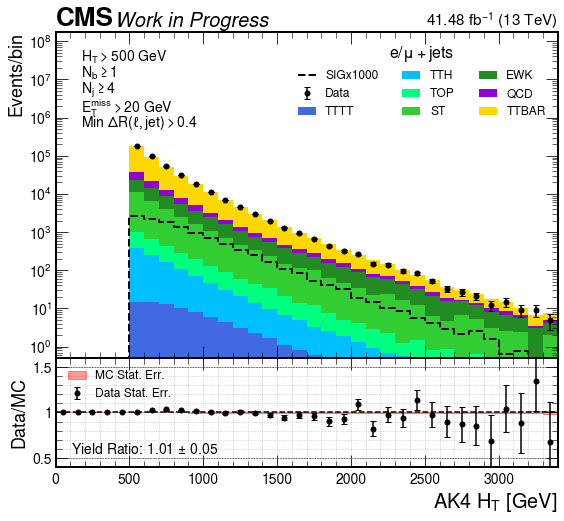

In [17]:
yscale = "log"
blind = False
plt.style.use( hep.style.CMS )
fig, subplots = plt.subplots( 2, 1, gridspec_kw = { "height_ratios": [3,1], "hspace": 0 }, figsize = (9,8) )
hep.cms.text( "Work in Progress", fontsize = 20, ax = subplots[0] )
hep.cms.lumitext( lumimap[era] + " (13 TeV)", fontsize = 16, ax = subplots[0] )
if not blind:
    if channel.value == "isElectron":
        data_hist = hist["DATA"]["EGamma_hadd.root"][0] if era == "2018" else hist["DATA"]["SingleElectron_hadd.root"][0]
    elif channel.value == "isMuon":
        data_hist = hist["DATA"]["SingleMuon_hadd.root"][0]
    else:
        data_hist = hist["DATA"]["SingleMuon_hadd.root"][0] + hist["DATA"]["EGamma_hadd.root"][0] if era == "2018" else hist["DATA"]["SingleMuon_hadd.root"][0] + hist["DATA"]["SingleElectron_hadd.root"][0]
    subplots[0].errorbar( 
        0.5 * ( bins[1:] + bins[:-1] ), data_hist,
        yerr = np.sqrt( data_hist ),
        ls = "", marker = "o", ms = 5, capsize = 3, color = "k", label = "Data"
    )
bottom = np.zeros( len( bins ) - 1 )
for g in fBKG:
    try:
        subplots[0].bar(
            0.5 * ( bins[1:] + bins[:-1] ), hist_norm["BKG"][g][0], width = bins[:-1] - bins[1:], bottom = bottom, 
            align = "center", color = colormap[g], label = g
        )
        bottom += hist_norm["BKG"][g][0]
    except:
        pass


subplots[0].step(
    0.5 * ( bins[1:] + bins[:-1] ), ( hist_norm["SIG"][fSIG[0]][0] + hist_norm["SIG"][fSIG[1]][0] ) * 1000, label = "SIGx1000",
    color = "k", ls = "--", lw = "2", where = "mid"
)

    
if not blind:
    subplots[1].errorbar(
        0.5 * ( bins[1:] + bins[:-1] ), ratio, yerr = ratio_err_data,
        color = "k", ls = "", marker = "o", ms = 5, capsize = 3, label = "Data Stat. Err."
    )
    subplots[1].fill_between(
        0.5 * ( bins[1:] + bins[:-1] ),
        y1 = 1 - np.array(ratio_err_MC), y2 = 1 + np.array(ratio_err_MC),
        color = "r", alpha = 0.4, step = "mid", label = "MC Stat. Err."
    )
subplots[1].hlines( 1, bins[0], bins[-1], color = "k", ls = "--", lw = 1.5 )
subplots[1].hlines( 0.5, bins[0], bins[-1], color = "k", ls = "--", lw = 0.5 )
subplots[1].hlines( 1.5, bins[0], bins[-1], color = "k", ls = "--", lw = 0.5 )

subplots[0].set_xlim( bins[1], bins[-2] )
subplots[1].set_xlim( bins[1], bins[-2] )

i_select = 0
for selection_ in sorted( selection ):
    if selection_[0] in [ "isElectron", "isMuon" ]: continue
    subplots[0].annotate( selection_[3], ( 0.05, 0.95 - i_select * 0.05 ), xycoords = "axes fraction", fontsize = 14, ha = "left", va = "top" )
    i_select += 1

#subplots[0].annotate( "With deepJet SF, No Renormalization", ( 0.95, 0.6 ), xycoords = "axes fraction", bbox = dict( boxstyle="Square,pad=0.5",fc="white",ec="red" ), fontsize = 14, ha = "right", va = "top" )
if not blind:
    subplots[1].annotate( "Yield Ratio: {:.2f} $\pm$ {:.2f}".format( float( data_yield_tot ) / float( mc_yield_tot ), data_mc_err ), ( 0.03, 0.09 ), xycoords = "axes fraction", fontsize = 14, ha = "left", va = "bottom" )
    
if yscale == "log":
    subplots[0].set_ylim( 0.5, np.max(data_hist) * 10**3 )
    subplots[1].set_ylim( 0.4, 1.6 )
else:
    subplots[0].set_ylim( -2000, 50000 )
    subplots[1].set_ylim( 0.4, 1.6 )

if "PtOrdered" in variable_plot.value:
    subplots[0].set_ylabel( "Jets/bin", fontsize = 18 )
else:
    subplots[0].set_ylabel( "Events/bin", fontsize = 18 )
subplots[1].set_ylabel( "Data/MC", fontsize = 18, ha = "center", x = 1.0 )
subplots[1].set_xlabel( variable_labels[ variable_plot.value ][0], fontsize = 20 )

subplots[1].tick_params( labelsize = 14, which = "major" )
subplots[1].grid( which = "both", linestyle = ":" )

legend_title = "$e/\mu+jets$"
if channel.value == "isElectron": legend_title = "$e+jets$"
if channel.value == "isMuon": legend_title = "$\mu+jets$"

subplots[0].set_yscale(yscale)
subplots[0].set_xticklabels([])
subplots[1].set_yticks([0.5,1,1.5])
subplots[1].set_yticklabels([0.5,1,1.5])
subplots[0].tick_params( labelsize = 14, which = "major" )
subplots[0].legend( loc = "upper right", fontsize = 12, title = legend_title, title_fontsize = 16, ncol = 3 )
subplots[1].legend( loc = "upper left", fontsize = 12 )

if not os.path.exists( os.path.join( os.getcwd(), "input_plots_" + postfix, era ) ):
    os.system( "mkdir -p {}".format( os.path.join( os.getcwd(), "input_plots_" + postfix, era ) ) )

file_name = "_".join( [ variable_plot.value, channel.value, era ] ) 
    
plt.savefig( os.path.join( os.getcwd(), "input_plots_" + postfix, era, file_name ) )
plt.show()
plt.close()